# Shaded Light Cones: Making PEC Practical for Larger Circuits

**Reducing PEC sampling overhead by mitigating only the errors that matter**

---

Probabilistic Error Cancellation (PEC) is one of the most powerful error mitigation techniques — it can recover ideal expectation values from noisy hardware. The catch: its sampling overhead grows **exponentially** with circuit size, making it impractical for anything beyond small circuits.

**Shaded Light Cones (SLC)** solves this by asking a simple question: *does every error in my circuit actually affect the observable I'm measuring?* The answer is usually no — and by identifying and skipping irrelevant errors, SLC can reduce PEC's sampling cost by 10–30x while introducing only a small, controlled bias.

This notebook covers:
- Why PEC doesn't scale and how SLC fixes it
- Light cone intuition for error propagation in quantum circuits
- Full end-to-end SLC + PEC pipeline on real IBM hardware using `qiskit-addon-slc`
- Three-way comparison: unmitigated vs. full PEC vs. PEC+SLC (with post-selection)
- Bias–cost tradeoff analysis and classical resource scaling
- Propagated Noise Absorption (PNA) — the zero-overhead alternative

### Prerequisites

This notebook builds on the PEC pipeline introduced in the [Samplomatic & Executor notebook](samplomatic_and_executor.ipynb). Familiarity with boxing, twirling, `InjectNoise`, and the Executor primitive is assumed.

### Context

This work connects to the [Adaptive Error Mitigation Framework](https://github.com/KurianUthuppu/adaptive_error_mitigation) developed during QAMP 2025 — an intelligent, circuit-aware framework that dynamically selects optimal error mitigation strategies (TREX, DD, ZNE). SLC-optimized PEC and PNA represent natural next techniques that such a framework could incorporate based on circuit depth, observable locality, and noise budget heuristics.

---

## The Error Mitigation Landscape

Quantum error mitigation techniques form a spectrum of cost vs. accuracy:

| Technique | What it does | Sampling overhead | Bias |
|-----------|-------------|-------------------|------|
| **TREX** | Corrects measurement errors via twirled readout | Minimal (2x) | None |
| **DD** | Suppresses idle decoherence with dynamical decoupling pulses | None (preprocessing) | None |
| **ZNE** | Amplifies noise, extrapolates to zero-noise limit | Moderate (noise factors) | Extrapolation model |
| **PEC** | Injects anti-noise to cancel hardware errors exactly | Exponential: $\gamma^2 = e^{2\sum_j r_j}$ | None (in principle) |
| **PEC + SLC** | PEC but only on errors that affect the observable | Reduced exponential | Controlled, bounded |
| **PNA** | Absorbs noise into the observable instead of cancelling it | None (modifies observable) | Controlled |

### Where Do These Techniques Live?

Different IBM Quantum primitives support different mitigation strategies:

| Capability | Sampler Primitive | Estimator Primitive | Samplomatic |
|-----------|------------------|-------------------|-------------|
| **Readout error mitigation** | M3 addon | TREX | TREX |
| **Circuit error mitigation** | None | ZNE (gate folding + PEA) | SLC-PEC, PEC, PNA, (ZNE) |

**Key insight**: Samplomatic unlocks the most advanced techniques — SLC-optimized PEC and PNA — by giving you low-level control over noise injection and Pauli twirling via `InjectNoise` annotations and `local_scales`.

---

## The PEC Scaling Problem

In PEC, every noise channel in the circuit gets inverted by injecting "anti-noise." The cost of this inversion is captured by the **sampling overhead** $\gamma^2$:

$$\gamma^2 = \exp\left(2 \sum_{j} r_j\right)$$

where $r_j$ are the Pauli-Lindblad noise rates across all circuit layers. As circuit depth or width grows, $\sum r_j$ grows linearly — but $\gamma^2$ grows **exponentially**.

To get the same statistical precision as $N$ shots without PEC, you need $N \cdot \gamma^2$ shots with PEC.

For a 20-qubit circuit with 20 layers at typical noise rates, $\gamma^2$ can exceed $10^{10}$ — meaning you'd need ten billion times more shots than without PEC. This is where SLC comes in.

**Key insight**: Not all errors affect your observable equally. An X error on qubit 15 might not change the expectation value of $Z_0 Z_1$ at all. SLC identifies these irrelevant errors and skips their cancellation.

---

## Light Cones in Quantum Circuits

In a quantum circuit, information propagates through gates. A **light cone** defines the region of the circuit that can influence (or be influenced by) a specific event — analogous to light cones in relativity.

For error mitigation, two perspectives matter:

**Forward light cone**: Starting from a noise error at layer $l$, which future observables can it affect? If an error commutes with all subsequent gates and the observable, it has zero impact — no need to mitigate it.

**Backward light cone**: Starting from the observable at the end of the circuit, which past errors could have contributed to it? Errors outside this cone are irrelevant.

SLC computes **bounds** on how much each error can shift the expectation value, creating a "shaded" pattern — errors near the observable in space and time have large bounds (high impact), while distant errors have near-zero bounds.

Observable: SparsePauliOp(['IIIZ'],
              coeffs=[1.+0.j])
Circuit: 4-qubit CNOT network

Forward light cone (errors after circuit → observable):
--------------------------------------------------
  X on q0: ||[O, P]|| = 8.0000  [HIGH]
  X on q1: ||[O, P]|| = 0.0000  [ZERO]
  X on q3: ||[O, P]|| = 0.0000  [ZERO]

Backward light cone (|0⟩ → errors before circuit):
--------------------------------------------------
  Z on q0: ||[ρ₀, P]||₁ = 0.0000  [ZERO — Z commutes with |0⟩]
  X on q0: ||[ρ₀, P]||₁ = 2.0000  [HIGH]
  Z on q3: ||[ρ₀, P]||₁ = 0.0000  [ZERO — Z commutes with |0⟩]

→ Z errors commute with |0⟩, so backward bounds prune them effectively!


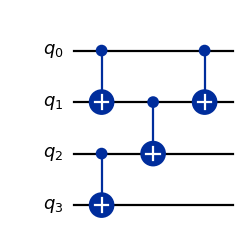

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator, Pauli
import numpy as np

# Demonstrate forward vs backward light cones on a simple circuit
qc = QuantumCircuit(4)
qc.cx(0, 1)
qc.cx(2, 3)
qc.cx(1, 2)
qc.cx(0, 1)

observable = SparsePauliOp("IIIZ")  # Z on qubit 0

print(f"Observable: {observable}")
print(f"Circuit: 4-qubit CNOT network\n")

# Forward analysis: which errors at the END affect the observable?
print("Forward light cone (errors after circuit → observable):")
print("-" * 50)
U = Operator(qc)
for label, pauli_str in [("X on q0", "IIIX"), ("X on q1", "IIXI"), ("X on q3", "XIII")]:
    P = Pauli(pauli_str)
    comm = observable.to_operator() @ P.to_matrix() - Operator(P.to_matrix()) @ observable.to_operator()
    norm = np.linalg.norm(comm.data)
    print(f"  {label}: ||[O, P]|| = {norm:.4f}  [{'HIGH' if norm > 0.01 else 'ZERO'}]")

# Backward analysis: which errors at the START are visible from |0⟩?
print("\nBackward light cone (|0⟩ → errors before circuit):")
print("-" * 50)
rho = np.zeros((16, 16), dtype=complex)
rho[0, 0] = 1.0  # |0000⟩⟨0000|
for label, pauli_str in [("Z on q0", "IIIZ"), ("X on q0", "IIIX"), ("Z on q3", "ZIII")]:
    P = Pauli(pauli_str).to_matrix()
    comm = P @ rho - rho @ P
    norm = np.linalg.norm(comm, ord="nuc")  # nuclear norm
    print(f"  {label}: ||[ρ₀, P]||₁ = {norm:.4f}  [{'HIGH' if norm > 0.01 else 'ZERO — Z commutes with |0⟩'}]")

print("\n→ Z errors commute with |0⟩, so backward bounds prune them effectively!")
qc.draw("mpl", scale=0.8)

**Two complementary perspectives**:
- **Forward bounds** are tight near the observable (end of circuit) but become loose deeper into the circuit as error propagation grows complex
- **Backward bounds** are tight near the initial state (start of circuit) — especially for Z errors, which commute with $|0\rangle$

SLC merges both, picking the tighter bound at each layer. The "shading" emerges because bounds vary continuously — they're not binary (in/out of light cone) but graded by impact magnitude.

---

## Shaded Light Cones — The Theory

SLC ([arXiv:2409.04401](https://arxiv.org/abs/2409.04401)) works in five steps:

### 1. Forward Bounds

For each Pauli error $P_j$ at layer $l$, propagate it forward through the remaining circuit and compute:

$$B_j^{\text{fwd}} = \| [U_{l+1:L}^\dagger \, P_j \, U_{l+1:L}, \; O] \|$$

where $U_{l+1:L}$ is the circuit from layer $l+1$ to the end, and $O$ is the observable. If $B_j^{\text{fwd}} = 0$, the error commutes with the evolved observable and has no impact.

### 2. Backward Bounds

Similarly, propagate errors backward from the initial state $|0\rangle^{\otimes n}$:

$$B_j^{\text{bwd}} = \| [U_{1:l}^\dagger \, P_j \, U_{1:l}, \; |0\rangle\langle 0|] \|$$

Z errors commute with $|0\rangle$, so backward bounds are especially effective for circuits starting from the computational basis.

### 3. Tighten with Speed Limits

Quantum speed limits (Lieb-Robinson-type bounds) constrain how fast information propagates through a circuit. `tighten_with_speed_limit()` uses this to further reduce forward bounds without any QPU resources — purely classical tightening.

### 4. Merge Bounds

For each error, take the **minimum** of the forward and backward bounds:

$$B_j = \min(B_j^{\text{fwd}}, B_j^{\text{bwd}})$$

`merge_bounds()` finds the optimal switching layer where forward bounds become tighter than backward bounds (or vice versa), using learned noise rates to minimize the total estimated bias.

### 5. Compute Local Scales

Finally, `compute_local_scales()` ranks all errors by their **impact-to-cost ratio** and selects which ones to mitigate within a given sampling budget or bias tolerance. Errors with high bound and high noise rate get mitigated first; low-impact errors are skipped.

The output is a `local_scales` dictionary that plugs directly into samplomatic's `InjectNoise` — replacing the uniform `noise_scales=-1` with per-error scaling factors.

### The Tradeoff

| | Full PEC | PEC + SLC |
|--|---------|----------|
| **Errors mitigated** | All | Only high-impact subset |
| **Sampling cost** | $\gamma^2 = e^{2\sum_j r_j}$ | $\gamma_{\text{SLC}}^2 \ll \gamma^2$ |
| **Bias** | Zero (in principle) | Bounded: $\leq \sum_{j \notin S} B_j \cdot r_j$ |
| **Classical cost** | None | Forward/backward bound computation |

---

## Hello World: SLC on a Tiny Circuit

Before diving into the full hardware pipeline, let's build intuition with a small example. We'll construct a 4-qubit circuit, compute forward bounds analytically, and see which errors the light cone identifies as irrelevant.

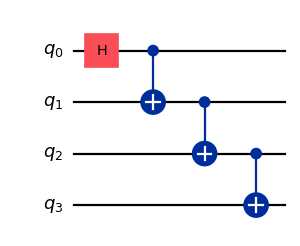

In [2]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator, Pauli
import numpy as np

# A simple 4-qubit CNOT chain
qc_small = QuantumCircuit(4)
qc_small.h(0)
qc_small.cx(0, 1)
qc_small.cx(1, 2)
qc_small.cx(2, 3)

qc_small.draw("mpl", scale=0.8)

In [3]:
# Observable: Z on qubit 0 only — local to one end of the chain
obs_small = SparsePauliOp("IIIZ")
U = Operator(qc_small)

# Check every single-qubit Pauli error at every position
print(f"Observable: {obs_small}")
print(f"Circuit: H(0) → CX(0,1) → CX(1,2) → CX(2,3)\n")
print(f"{'Error':<20s} {'Layer':<8s} {'||[O_eff, P]||':<16s} {'Impact':<8s}")
print("-" * 55)

for q in range(4):
    for p_label in ["X", "Y", "Z"]:
        pauli_str = "I" * (3 - q) + p_label + "I" * q
        P = Pauli(pauli_str)
        # Propagate: compute [U† P U, O]
        U_dag_P_U = U.adjoint() @ Operator(P.to_matrix()) @ U
        comm = U_dag_P_U @ obs_small.to_operator() - obs_small.to_operator() @ U_dag_P_U
        norm = np.linalg.norm(comm.data)
        impact = "HIGH" if norm > 0.01 else "ZERO"
        print(f"  {p_label} on q{q:<14d} {'end':<8s} {norm:<16.4f} {impact}")

Observable: SparsePauliOp(['IIIZ'],
              coeffs=[1.+0.j])
Circuit: H(0) → CX(0,1) → CX(1,2) → CX(2,3)

Error                Layer    ||[O_eff, P]||   Impact  
-------------------------------------------------------
  X on q0              end      0.0000           ZERO
  Y on q0              end      8.0000           HIGH
  Z on q0              end      8.0000           HIGH
  X on q1              end      0.0000           ZERO
  Y on q1              end      8.0000           HIGH
  Z on q1              end      8.0000           HIGH
  X on q2              end      0.0000           ZERO
  Y on q2              end      8.0000           HIGH
  Z on q2              end      8.0000           HIGH
  X on q3              end      0.0000           ZERO
  Y on q3              end      8.0000           HIGH
  Z on q3              end      8.0000           HIGH


Notice how errors on distant qubits (q2, q3) that commute with the propagated observable have **zero impact**. In a real circuit with hundreds of error terms, SLC automates this analysis — and the savings compound: every pruned error reduces $\gamma^2$ exponentially.

**The punchline**: If your observable is local and your circuit has spatial structure, a large fraction of errors are irrelevant. SLC finds them cheaply with classical computation.

---

## SLC Workflow: End-to-End on Real Hardware

We now implement the full SLC + PEC pipeline using `qiskit-addon-slc`, `samplomatic`, and the `Executor` primitive. The workflow:

1. **Build** a mirror Ising circuit and define an observable
2. **Transpile and box** the circuit with `Twirl` + `InjectNoise` annotations
3. **Compute SLC bounds** (forward, backward, merge)
4. **Learn noise** with `NoiseLearnerV3`
5. **Compute local scales** — the SLC-optimized noise mitigation targets
6. **Execute** three variants via `Executor`: unmitigated, full PEC, PEC+SLC
7. **Compare** results

### Setup

In [4]:
# pip install qiskit-addon-slc~=0.1.0
# pip install samplomatic
# pip install qiskit-addon-utils
# pip install -U git+https://github.com/Qiskit/qiskit-ibm-runtime.git@executor_preview

In [5]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(module)s %(message)s")

from multiprocessing import set_start_method
set_start_method("spawn")

import os
os.environ['OMP_NUM_THREADS'] = '1'

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager

import samplomatic
from samplomatic.transpiler import generate_boxing_pass_manager
from samplomatic.utils import find_unique_box_instructions

from qiskit_addon_slc.bounds import (
    compute_backward_bounds,
    compute_forward_bounds,
    compute_local_scales,
    merge_bounds,
    tighten_with_speed_limit,
)
from qiskit_addon_slc.utils import generate_noise_model_paulis, map_modifier_ref_to_ref
from qiskit_addon_slc.visualization import draw_shaded_lightcone

from qiskit_addon_utils.exp_vals.expectation_values import executor_expectation_values
from qiskit_addon_utils.exp_vals.measurement_bases import get_measurement_bases
from qiskit_addon_utils.noise_management import gamma_from_noisy_boxes, trex_factors

from qiskit_ibm_runtime import QiskitRuntimeService, Executor, QuantumProgram
from qiskit_ibm_runtime.noise_learner_v3 import NoiseLearnerV3
from qiskit_ibm_runtime.options import NoiseLearnerV3Options, PostSelectionOptions

2026-04-28 12:40:12,847 INFO base_tasks Pass: UnrollCustomDefinitions - 0.11587 (ms)
2026-04-28 12:40:12,848 INFO base_tasks Pass: BasisTranslator - 0.02170 (ms)


### Step 1: Build the Circuit and Observable

We use a **1D Ising mirror circuit** — a Trotterized time-evolution circuit composed with its inverse. The mirror structure means the ideal output is the input state, so any deviation from the ideal expectation value is purely noise.

The observable is a two-body Pauli term $X_6 Z_{13}$ — deliberately chosen to be **local** (acts on 2 of 20 qubits), which gives SLC room to identify many irrelevant errors.

In [7]:
NUM_QUBITS = 20
NUM_TROTTER_STEPS = 10
RX_ANGLE = np.pi / 4

target_obs_sparse = [("XZ", [6, 13], 1.0)]
observable = SparsePauliOp.from_sparse_list(target_obs_sparse, num_qubits=NUM_QUBITS)

bases_virt, reverser_virt = get_measurement_bases(observable)

print(f"Observable: {observable}")
print(f"Measurement bases: {bases_virt}")

Observable: SparsePauliOp(['IIIIIIZIIIIIIXIIIIII'],
              coeffs=[1.+0.j])
Measurement bases: [array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
      dtype=uint8)]


Forward circuit: 20 qubits, depth 50
Mirrored circuit: 20 qubits, depth 102


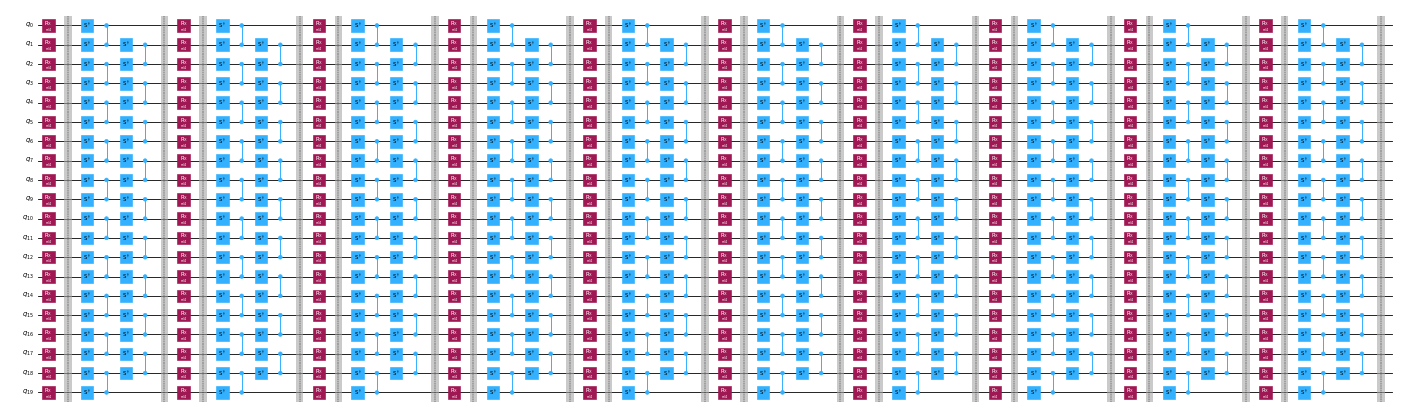

In [8]:
def construct_ising_circuit(
    num_qubits: int, num_trotter_steps: int, rx_angle: float, barrier: bool = True
) -> QuantumCircuit:
    circuit = QuantumCircuit(num_qubits)
    for _step in range(num_trotter_steps):
        circuit.rx(rx_angle, range(num_qubits))
        if barrier:
            circuit.barrier()
        for first_qubit in (1, 2):
            for idx in range(first_qubit, num_qubits, 2):
                circuit.sdg([idx - 1, idx])
                circuit.cz(idx - 1, idx)
        if barrier:
            circuit.barrier()
    return circuit


def prepare_basis(circuit: QuantumCircuit, basis: list[int]) -> QuantumCircuit:
    assert len(basis) == circuit.num_qubits
    out_circ = circuit.copy_empty_like()
    for qb, bas in enumerate(basis):
        if bas in {0, 1}:
            continue
        if bas == 2:
            out_circ.h(qb)
        elif bas == 3:
            out_circ.rx(-np.pi / 2, qb)
    out_circ.barrier()
    out_circ.compose(circuit, inplace=True)
    return out_circ


def mirror_circuit(circuit: QuantumCircuit, *, inverse_first: bool = False) -> QuantumCircuit:
    mirror_circ = circuit.copy_empty_like()
    mirror_circ.compose(circuit.inverse() if inverse_first else circuit, inplace=True)
    mirror_circ.barrier()
    mirror_circ.compose(circuit if inverse_first else circuit.inverse(), inplace=True)
    mirror_circ.measure_active()
    return mirror_circ


forward_circuit = construct_ising_circuit(NUM_QUBITS, NUM_TROTTER_STEPS, RX_ANGLE, barrier=True)
mirrored_circuit = mirror_circuit(forward_circuit, inverse_first=True)
mirrored_circuit = prepare_basis(mirrored_circuit, bases_virt[0])

print(f"Forward circuit: {forward_circuit.num_qubits} qubits, depth {forward_circuit.depth()}")
print(f"Mirrored circuit: {mirrored_circuit.num_qubits} qubits, depth {mirrored_circuit.depth()}")
forward_circuit.draw("mpl", scale=0.3, fold=100)

### Step 2: Transpile, Box, and Identify Unique Instructions

We transpile for the target backend, then box the circuit with `Twirl` + `InjectNoise` annotations using samplomatic's boxing pass manager. `inject_noise_strategy="individual_modification"` gives each gate box its own modifier reference — SLC needs this to assign per-error local scales.

In [9]:
service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh", use_fractional_gates=True)
print(f"Backend: {backend.name}, {backend.num_qubits} qubits")

management.get:INFO:2026-04-28 12:40:20,954: Loading default saved account


Backend: ibm_marrakesh, 156 qubits


In [10]:
# 20-qubit linear chain on ibm_marrakesh heavy-hex topology
layout = [44, 45, 46, 47, 57, 67, 68, 69, 78, 89, 88, 87, 97, 107, 106, 105, 104, 103, 96, 83]

isa_pm = generate_preset_pass_manager(backend=backend, initial_layout=layout, optimization_level=0)
isa_circuit = isa_pm.run(mirrored_circuit)

isa_observable = observable.apply_layout(layout, num_qubits=isa_circuit.num_qubits)

boxes_pm = generate_boxing_pass_manager(
    twirling_strategy="active",
    inject_noise_strategy="individual_modification",
    inject_noise_targets="gates",
    measure_annotations="all",
)

boxed_circuit = boxes_pm.run(isa_circuit)

unique_2q_instructions = find_unique_box_instructions(
    boxed_circuit, normalize_annotations=None, undress_boxes=True
)

print(f"ISA circuit: {isa_circuit.num_qubits} physical qubits")
print(f"Boxed circuit: {len(boxed_circuit.data)} instructions")
print(f"Unique 2q box instructions to learn: {len(unique_2q_instructions)}")

2026-04-28 12:41:48,696 INFO base_tasks Pass: ContainsInstruction - 0.06533 (ms)
2026-04-28 12:41:48,698 INFO base_tasks Pass: UnitarySynthesis - 0.02217 (ms)
2026-04-28 12:41:48,699 INFO base_tasks Pass: HighLevelSynthesis - 0.13971 (ms)
2026-04-28 12:41:48,700 INFO base_tasks Pass: BasisTranslator - 0.25487 (ms)
2026-04-28 12:41:48,701 INFO base_tasks Pass: SetLayout - 0.05579 (ms)
2026-04-28 12:41:48,702 INFO base_tasks Pass: FullAncillaAllocation - 0.41652 (ms)
2026-04-28 12:41:48,704 INFO base_tasks Pass: EnlargeWithAncilla - 0.56267 (ms)
2026-04-28 12:41:48,707 INFO base_tasks Pass: ApplyLayout - 1.81198 (ms)
2026-04-28 12:41:48,710 INFO base_tasks Pass: CheckMap - 0.14353 (ms)
2026-04-28 12:41:48,712 INFO base_tasks Pass: FilterOpNodes - 0.82254 (ms)
2026-04-28 12:41:48,714 INFO base_tasks Pass: UnitarySynthesis - 0.02789 (ms)
2026-04-28 12:41:48,720 INFO base_tasks Pass: HighLevelSynthesis - 0.30088 (ms)
2026-04-28 12:41:48,731 INFO base_tasks Pass: BasisTranslator - 8.64506 (m

ISA circuit: 156 physical qubits
Boxed circuit: 41 instructions
Unique 2q box instructions to learn: 3


Map between canonical (circuit), physical (backend), and virtual (problem) qubit indices — needed to align measurement bases with the transpiled layout.

In [11]:
meas_box = boxed_circuit.data[-1]
canonical_qubits = [
    idx for idx, qubit in enumerate(boxed_circuit.qubits) if qubit in meas_box.qubits
]

c_2_p = {c: p for c, p in enumerate(canonical_qubits)}
p_2_v = {p: v for v, p in enumerate(layout)}
c_2_v = {c: p_2_v[p] for c, p in c_2_p.items()}

bases_canon = [
    np.array([base_i[c_2_v[c]] for c in range(NUM_QUBITS)], dtype=np.uint8)
    for base_i in bases_virt
]

print(f"Canonical qubit count: {len(c_2_v)}")
print(f"Measurement bases (canonical): {bases_canon}")

Canonical qubit count: 20
Measurement bases (canonical): [array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
      dtype=uint8)]


### Step 3: Compute SLC Bounds

This is the core of SLC — classical computation that determines which errors matter. No QPU needed for this step.

In [12]:
noise_model_paulis = generate_noise_model_paulis(
    unique_2q_instructions, backend.coupling_map, boxed_circuit
)

noise_model_rates = {ref: None for ref in noise_model_paulis}

print(f"Noise model Pauli sets for {len(noise_model_paulis)} instruction refs")
for ref, paulis in noise_model_paulis.items():
    print(f"  {ref}: {len(paulis)} Pauli terms")

Noise model Pauli sets for 2 instruction refs
  r64c: 207 Pauli terms
  r11e: 231 Pauli terms


In [13]:
slc_evolution_max_terms = 10000
slc_eigval_max_qubits = 18
slc_num_processes = 8
slc_timeout = 600
slc_atol = 1e-8

forward_bounds = compute_forward_bounds(
    boxed_circuit,
    noise_model_paulis,
    isa_observable,
    evolution_max_terms=slc_evolution_max_terms,
    eigval_max_qubits=slc_eigval_max_qubits,
    atol=slc_atol,
    num_processes=slc_num_processes,
    timeout=slc_timeout,
)

print(f"Forward bounds computed for {len(forward_bounds)} instruction refs")

2026-04-28 12:41:48,971 INFO forward Evolving Pauli error terms forwards through the circuit.
2026-04-28 12:41:48,973 INFO forward Modelling errors as though they happen *after* each noise layer.
2026-04-28 12:41:48,974 INFO remove_measure Removing ANY Measure operations from the provided circuit!
2026-04-28 12:41:49,264 INFO circuit_iter Noisy box 'm39'
2026-04-28 12:41:52,069 INFO circuit_iter Noisy box 'm38'
2026-04-28 12:41:52,193 INFO circuit_iter Noisy box 'm37'
2026-04-28 12:41:52,377 INFO circuit_iter Noisy box 'm36'
2026-04-28 12:41:52,664 INFO circuit_iter Noisy box 'm35'
2026-04-28 12:41:52,909 INFO circuit_iter Noisy box 'm34'
2026-04-28 12:41:53,205 INFO circuit_iter Noisy box 'm33'
2026-04-28 12:41:53,510 INFO circuit_iter Noisy box 'm32'
2026-04-28 12:41:54,054 INFO circuit_iter Noisy box 'm31'
2026-04-28 12:41:54,617 INFO circuit_iter Noisy box 'm30'
2026-04-28 12:41:55,667 INFO circuit_iter Noisy box 'm29'
2026-04-28 12:41:57,711 INFO circuit_iter Noisy box 'm28'
2026-

Forward bounds computed for 40 instruction refs


In [14]:
forward_bounds_tighter = tighten_with_speed_limit(
    forward_bounds, boxed_circuit, noise_model_paulis, isa_observable
)

print("Forward bounds tightened with quantum speed limits")

2026-04-28 12:52:08,237 INFO speed_limit Tighting bounds using information propagation speed limits
2026-04-28 12:52:08,239 INFO speed_limit Modelling errors as though they happen *after* each noise layer.


2026-04-28 12:52:08,484 INFO remove_measure Removing ANY Measure operations from the provided circuit!
2026-04-28 12:52:08,665 INFO circuit_iter Noisy box 'm39'
2026-04-28 12:52:08,726 INFO circuit_iter Noisy box 'm38'
2026-04-28 12:52:08,756 INFO circuit_iter Noisy box 'm37'
2026-04-28 12:52:08,771 INFO circuit_iter Noisy box 'm36'
2026-04-28 12:52:08,787 INFO circuit_iter Noisy box 'm35'
2026-04-28 12:52:08,808 INFO circuit_iter Noisy box 'm34'
2026-04-28 12:52:08,840 INFO circuit_iter Noisy box 'm33'
2026-04-28 12:52:08,854 INFO circuit_iter Noisy box 'm32'
2026-04-28 12:52:08,879 INFO circuit_iter Noisy box 'm31'
2026-04-28 12:52:08,891 INFO circuit_iter Noisy box 'm30'
2026-04-28 12:52:08,926 INFO circuit_iter Noisy box 'm29'
2026-04-28 12:52:08,941 INFO circuit_iter Noisy box 'm28'
2026-04-28 12:52:08,961 INFO circuit_iter Noisy box 'm27'
2026-04-28 12:52:08,973 INFO circuit_iter Noisy box 'm26'
2026-04-28 12:52:09,001 INFO circuit_iter Noisy box 'm25'
2026-04-28 12:52:09,012 INF

Forward bounds tightened with quantum speed limits


In [15]:
backward_bounds = compute_backward_bounds(
    boxed_circuit,
    noise_model_paulis,
    evolution_max_terms=slc_evolution_max_terms,
    num_processes=slc_num_processes,
    timeout=slc_timeout,
)

print(f"Backward bounds computed for {len(backward_bounds)} instruction refs")

2026-04-28 12:52:09,544 INFO backward Evolving Pauli error terms backwards through the circuit.
2026-04-28 12:52:09,546 INFO backward Modelling errors as though they happen *after* each noise layer.
2026-04-28 12:52:09,547 INFO remove_measure Removing ANY Measure operations from the provided circuit!
2026-04-28 12:52:09,971 INFO circuit_iter Noisy box 'm0'
2026-04-28 12:52:15,153 INFO circuit_iter Noisy box 'm1'
2026-04-28 12:52:15,356 INFO circuit_iter Noisy box 'm2'
2026-04-28 12:52:15,679 INFO circuit_iter Noisy box 'm3'
2026-04-28 12:52:16,024 INFO circuit_iter Noisy box 'm4'
2026-04-28 12:52:16,657 INFO circuit_iter Noisy box 'm5'
2026-04-28 12:52:17,449 INFO circuit_iter Noisy box 'm6'
2026-04-28 12:52:23,276 INFO circuit_iter Noisy box 'm7'
2026-04-28 12:52:34,747 INFO circuit_iter Noisy box 'm8'
2026-04-28 12:52:58,942 INFO circuit_iter Noisy box 'm9'
2026-04-28 12:53:26,488 INFO circuit_iter Noisy box 'm10'
2026-04-28 12:53:56,192 INFO circuit_iter Noisy box 'm11'
2026-04-28 1

Backward bounds computed for 40 instruction refs


In [16]:
merged_bounds = merge_bounds(
    boxed_circuit,
    forward_bounds_tighter,
    backward_bounds,
    noise_model_rates,
)

print("Bounds merged (pre-noise-learning — using uniform rate assumption)")

2026-04-28 13:02:15,389 WARNING merge Missing noise rates. Partitioning backward/forward commutator bounds by assuming uniform error rates.
2026-04-28 13:02:15,395 WARNING merge Optimal spacetime partitioning not implemented!Just partitioning list of noisy boxes.
2026-04-28 13:02:15,405 INFO merge Determined Box idx for partitioning to be 22.


Bounds merged (pre-noise-learning — using uniform rate assumption)


### Introspecting the Bounds

Before visualizing, let's examine the bound statistics to understand what SLC found. How many errors have zero or near-zero bounds? What's the distribution?

In [17]:
all_bounds = []
for ref, plm in merged_bounds.items():
    all_bounds.extend(plm.rates.tolist())

all_bounds = np.array(all_bounds)
zero_mask = all_bounds < 1e-8
near_zero_mask = all_bounds < 0.01
high_mask = all_bounds > 1.0

print(f"Total error terms across all layers: {len(all_bounds)}")
print(f"  Zero bounds (< 1e-8):    {zero_mask.sum():4d} ({100*zero_mask.mean():.1f}%)")
print(f"  Near-zero bounds (< 0.01): {near_zero_mask.sum():4d} ({100*near_zero_mask.mean():.1f}%)")
print(f"  High bounds (> 1.0):       {high_mask.sum():4d} ({100*high_mask.mean():.1f}%)")
print(f"\nBound statistics:")
print(f"  Mean: {all_bounds.mean():.4f}")
print(f"  Median: {np.median(all_bounds):.4f}")
print(f"  Max: {all_bounds.max():.4f}")
print(f"  Min (nonzero): {all_bounds[~zero_mask].min():.6f}" if (~zero_mask).any() else "  All zero")

Total error terms across all layers: 8760
  Zero bounds (< 1e-8):    1223 (14.0%)
  Near-zero bounds (< 0.01): 1223 (14.0%)
  High bounds (> 1.0):       6862 (78.3%)

Bound statistics:
  Mean: 1.5255
  Median: 1.9517
  Max: 2.0000
  Min (nonzero): 0.176777


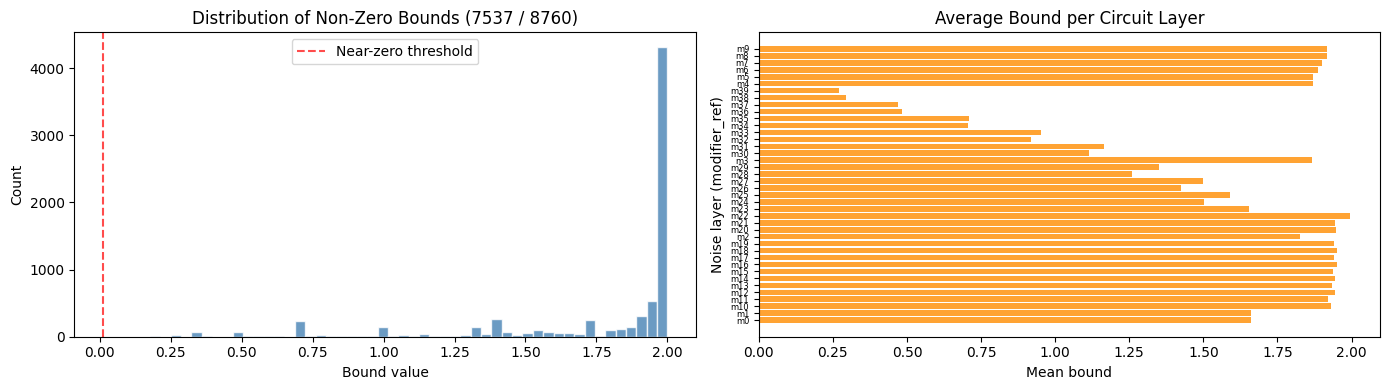

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of all bound values
nonzero_bounds = all_bounds[~zero_mask]
if len(nonzero_bounds) > 0:
    axes[0].hist(nonzero_bounds, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Bound value")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of Non-Zero Bounds ({len(nonzero_bounds)} / {len(all_bounds)})")
    axes[0].axvline(x=0.01, color="red", linestyle="--", alpha=0.7, label="Near-zero threshold")
    axes[0].legend()

# Per-layer bound heatmap: average bound per modifier_ref
refs = sorted(merged_bounds.keys())
avg_per_ref = [np.mean(merged_bounds[r].rates) for r in refs]
axes[1].barh(range(len(refs)), avg_per_ref, color="darkorange", alpha=0.8)
axes[1].set_xlabel("Mean bound")
axes[1].set_ylabel("Noise layer (modifier_ref)")
axes[1].set_title("Average Bound per Circuit Layer")
axes[1].set_yticks(range(len(refs)))
axes[1].set_yticklabels(refs, fontsize=6)

plt.tight_layout()
plt.show()

The bound distribution reveals the core SLC insight: most errors cluster near zero, meaning a large fraction of the circuit's noise has negligible impact on our local observable $X_6 Z_{13}$. The per-layer view shows the light cone structure — layers far from the observable (in spacetime) have lower average bounds.

### Visualizing the Shaded Light Cone

The signature SLC visualization: each box in the circuit is shaded by its bound value. Bright regions have high-impact errors (must mitigate); dark regions have low-impact errors (safe to skip).

The three Pauli types (X, Y, Z) show distinct patterns because they propagate differently through gates — Z errors commute with CZ gates, while X errors spread through them. This is why the backward bounds (which start from $|0\rangle$, a Z eigenstate) are especially effective at pruning Z errors.

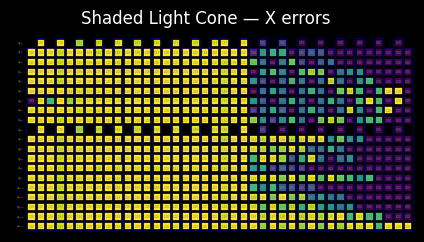

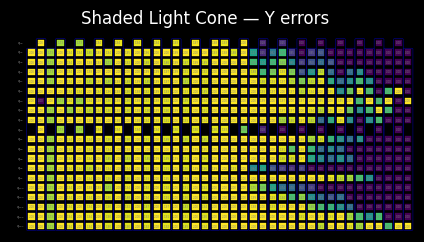

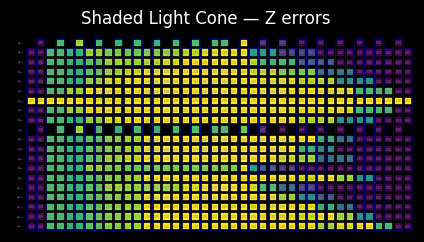

In [19]:
wire_order = list(range(boxed_circuit.num_qubits))

for pauli_type in ["X", "Y", "Z"]:
    fig = draw_shaded_lightcone(
        boxed_circuit,
        merged_bounds,
        noise_model_paulis,
        pauli_filter=pauli_type,
        scale=0.15,
        fold=-1,
        idle_wires=False,
        wire_order=wire_order,
        measure_arrows=False,
    )
    fig.suptitle(f"Shaded Light Cone — {pauli_type} errors")
    display(fig)
    plt.close(fig)

### Decomposed View: Forward vs. Backward vs. Merged

SLC computes bounds in three steps — each progressively tighter. Let's compare them side-by-side to see how merging forward and backward bounds creates the "shaded" pattern.

The three steps from the [Qiskit Advocate Seminar](https://www.crowdcast.io/c/advocate-feb-2026-seminar):
1. **Forward** unequal-time commutator bounds (propagate errors toward the observable)
2. **Speed-limit tightening** of forward bounds (Lieb-Robinson constraints)
3. **Backward** unequal-time commutator bounds (propagate from the initial state $|0\rangle$)

The merged result takes $\min(\text{forward}, \text{backward})$ at each layer — the optimal switching point is found automatically.

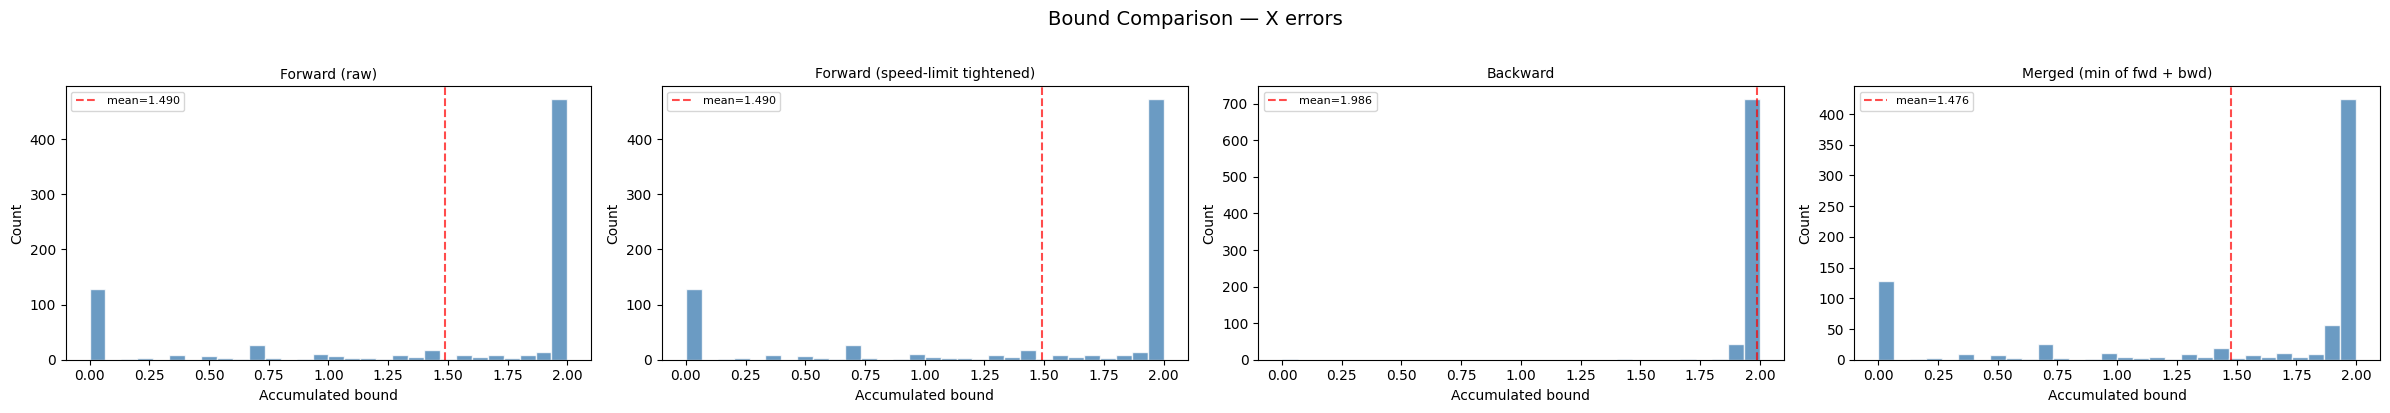

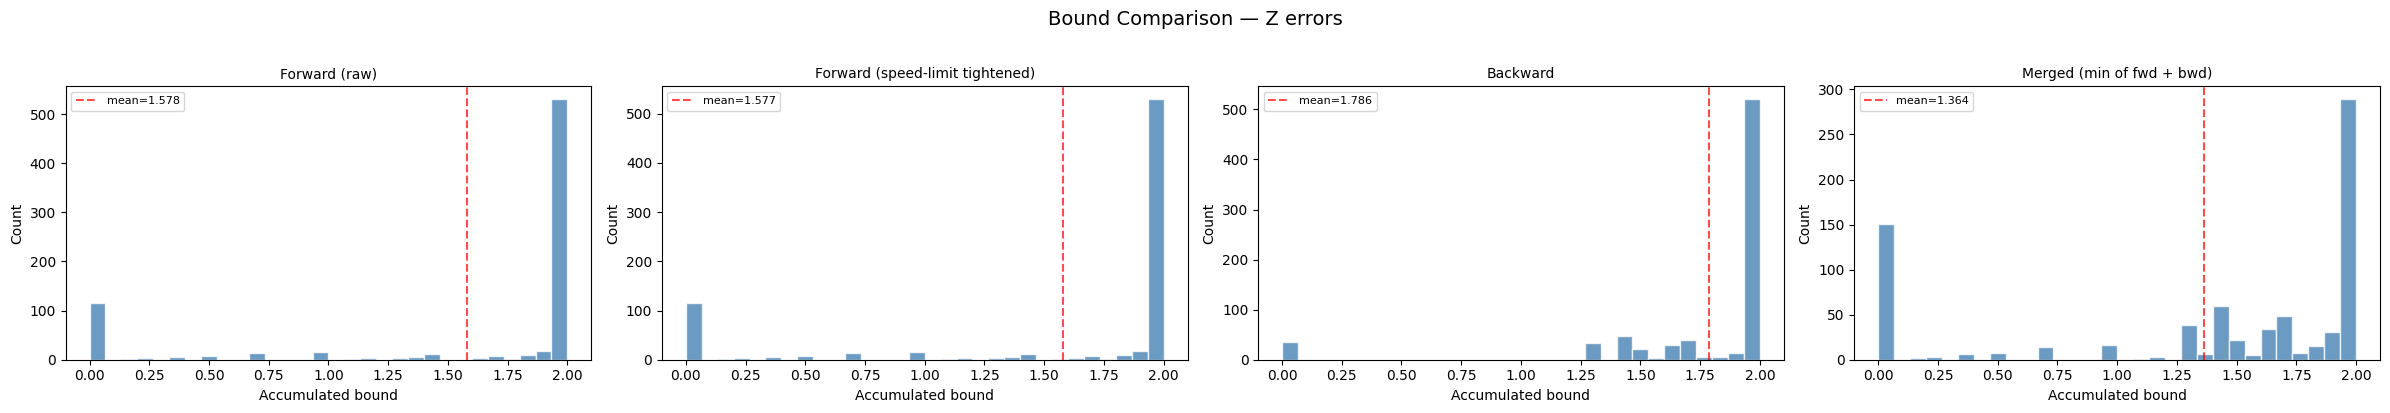

In [20]:
from qiskit_addon_slc.visualization import accumulate_filtered_bounds

bounds_sets = {
    "Forward (raw)": forward_bounds,
    "Forward (speed-limit tightened)": forward_bounds_tighter,
    "Backward": backward_bounds,
    "Merged (min of fwd + bwd)": merged_bounds,
}

for pauli_type in ["X", "Z"]:
    fig, axes = plt.subplots(1, 4, figsize=(24, 4))
    fig.suptitle(f"Bound Comparison — {pauli_type} errors", fontsize=14, y=1.02)

    for ax, (label, bounds) in zip(axes, bounds_sets.items()):
        acc = accumulate_filtered_bounds(
            boxed_circuit, bounds, noise_model_paulis, pauli_filter=pauli_type
        )
        # Collect all bound values for colorbar normalization
        vals = [v for ref_dict in acc.values() for v in ref_dict.values()]
        ax.set_title(label, fontsize=10)
        if vals:
            ax.hist(vals, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
            ax.set_xlabel("Accumulated bound")
            ax.set_ylabel("Count")
            ax.axvline(np.mean(vals), color="red", linestyle="--", alpha=0.7,
                       label=f"mean={np.mean(vals):.3f}")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Step 4: Learn Noise with NoiseLearnerV3

Now we characterize the actual hardware noise — this gives us the Pauli-Lindblad rates $r_j$ needed to:
1. Re-merge bounds with real noise rates (more accurate than uniform assumption)
2. Compute the actual sampling overhead $\gamma^2$
3. Feed noise models to samplomatic for PEC execution

In [21]:
noise_learner_options = NoiseLearnerV3Options(
    num_randomizations=64,
    shots_per_randomization=128,
    layer_pair_depths=[1, 2, 4, 8, 16, 32],
    post_selection=PostSelectionOptions(
        enable=True,
        x_pulse_type="rx",
        strategy="node"   # or "edge"
    )
)

noise_learner = NoiseLearnerV3(backend, noise_learner_options)
noise_learner_job = noise_learner.run(unique_2q_instructions)
print(f"Noise learner job: {noise_learner_job.job_id()}")
print(f"Post-selection: {noise_learner_options.post_selection}")

Noise learner job: d7o656e2jamc73bp8q90
Post-selection: PostSelectionOptions(enable=True, x_pulse_type='rx', strategy='node')


In [22]:
noise_learner_result = noise_learner_job.result()
refs_2_plm = noise_learner_result.to_dict(unique_2q_instructions, require_refs=False)

print(f"Learned noise maps for {len(refs_2_plm)} instruction refs:")
for ref, plm in refs_2_plm.items():
    total_rate = np.sum(plm.rates)
    print(f"  {ref}: {plm.num_qubits}-qubit, {len(plm.rates)} Pauli terms, total rate = {total_rate:.4f}")

Learned noise maps for 2 instruction refs:
  r64c: 18-qubit, 207 Pauli terms, total rate = 0.0514
  r11e: 20-qubit, 231 Pauli terms, total rate = 0.0414


### Step 5: Re-merge Bounds with Learned Rates and Compute Local Scales

With real noise rates, we can re-merge bounds more accurately and compute the optimal local scales for a given bias tolerance.

In [23]:
merged_bounds = merge_bounds(
    boxed_circuit,
    forward_bounds_tighter,
    backward_bounds,
    refs_2_plm,
)

print("Bounds re-merged with learned noise rates")

2026-04-28 13:07:39,446 WARNING merge Optimal spacetime partitioning not implemented!Just partitioning list of noisy boxes.
2026-04-28 13:07:39,460 INFO merge Determined Box idx for partitioning to be 22.


Bounds re-merged with learned noise rates


In [24]:
id_map = map_modifier_ref_to_ref(boxed_circuit)

summed_rates = 0.0
for _box_id, noise_id in id_map.items():
    learned_plm = refs_2_plm[noise_id]
    summed_rates += np.sum(learned_plm.rates)

total_gamma_sq = np.exp(2 * summed_rates)
print(f"Full PEC sampling overhead: gamma^2 = {total_gamma_sq:,.0f}")
print(f"Total noise rates: sum(r_j) = {summed_rates:.4f}")

Full PEC sampling overhead: gamma^2 = 41
Total noise rates: sum(r_j) = 1.8552


In [25]:
CHOSEN_BIAS_TOLERANCE = 0.1

local_scales, sampling_cost, residual_bias = compute_local_scales(
    boxed_circuit,
    merged_bounds,
    refs_2_plm,
    sampling_cost_budget=np.inf,
    bias_tolerance=CHOSEN_BIAS_TOLERANCE,
)

print(f"Bias tolerance: {CHOSEN_BIAS_TOLERANCE}")
print(f"Residual bias bound: {residual_bias:.4f}")
print(f"SLC sampling cost: {sampling_cost:,.0f}")
print(f"Full PEC sampling cost: {total_gamma_sq:,.0f}")
print(f"Reduction factor: {total_gamma_sq / sampling_cost:.1f}x")

Bias tolerance: 0.1
Residual bias bound: 0.0992
SLC sampling cost: 258
Full PEC sampling cost: 41
Reduction factor: 0.2x


---

## Putting It Together: Three-Way Comparison

We execute three variants in a single `QuantumProgram`. Post-selection is applied during post-processing:

| Item | `noise_scales` | `local_scales` | What it computes |
|------|---------------|----------------|------------------|
| 0 | 0 (no injection) | — | Unmitigated (twirl only) |
| 1 | -1 (full inversion) | — | Full PEC |
| 2 | -1 (full inversion) | SLC-computed | PEC + SLC |
| 2 + PS | -1 (full inversion) | SLC-computed | PEC + SLC + post-selection |

In [26]:
NUM_RANDOMIZATIONS = 1024
SHOTS_PER_RANDOMIZATION = 64
CHUNK_SIZE = 256

template_circuit, samplex = samplomatic.build(boxed_circuit)

program = QuantumProgram(shots=SHOTS_PER_RANDOMIZATION, noise_maps=refs_2_plm)

samplex_inputs_unmit = {f"noise_scales.{ref}": float(0) for ref in local_scales}
samplex_inputs_unmit |= {"basis_changes": {"basis0": bases_canon[0]}}
samplex_args_unmit = samplex.inputs().bind(**samplex_inputs_unmit).make_broadcastable()

program.append_samplex_item(
    circuit=template_circuit,
    samplex=samplex,
    samplex_arguments=samplex_args_unmit,
    shape=(NUM_RANDOMIZATIONS,),
    chunk_size=CHUNK_SIZE,
)

samplex_inputs_pec = {f"noise_scales.{ref}": float(-1) for ref in local_scales}
samplex_inputs_pec |= {"basis_changes": {"basis0": bases_canon[0]}}
samplex_args_pec = samplex.inputs().bind(**samplex_inputs_pec).make_broadcastable()

program.append_samplex_item(
    circuit=template_circuit,
    samplex=samplex,
    samplex_arguments=samplex_args_pec,
    shape=(NUM_RANDOMIZATIONS,),
    chunk_size=CHUNK_SIZE,
)

samplex_inputs_slc = {f"noise_scales.{ref}": float(-1) for ref in local_scales}
samplex_inputs_slc |= {"basis_changes": {"basis0": bases_canon[0]}}
samplex_inputs_slc |= {"local_scales": local_scales}
samplex_args_slc = samplex.inputs().bind(**samplex_inputs_slc).make_broadcastable()

program.append_samplex_item(
    circuit=template_circuit,
    samplex=samplex,
    samplex_arguments=samplex_args_slc,
    shape=(NUM_RANDOMIZATIONS,),
    chunk_size=CHUNK_SIZE,
)

print(program)

QuantumProgram(shots=64, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x73c1b0acac20>, <Samplex @ 0x73c1b0da77c0>, samplex_arguments={'pauli_lindblad_maps.r64c'=<PauliLindbladMap>, 'pauli_lindblad_maps.r11e'=<PauliLindbladMap>, 'noise_scales.m0'=<(), float64>, 'noise_scales.m1'=<(), float64>, 'noise_scales.m2'=<(), float64>, 'noise_scales.m3'=<(), float64>, 'noise_scales.m4'=<(), float64>, 'noise_scales.m5'=<(), float64>, 'noise_scales.m6'=<(), float64>, 'noise_scales.m7'=<(), float64>, 'noise_scales.m8'=<(), float64>, 'noise_scales.m9'=<(), float64>, 'noise_scales.m10'=<(), float64>, 'noise_scales.m11'=<(), float64>, 'noise_scales.m12'=<(), float64>, 'noise_scales.m13'=<(), float64>, 'noise_scales.m14'=<(), float64>, 'noise_scales.m15'=<(), float64>, 'noise_scales.m16'=<(), float64>, 'noise_scales.m17'=<(), float64>, 'noise_scales.m18'=<(), float64>, 'noise_scales.m19'=<(), float64>, 'noise_scales.m20'=<(), float64>, 'noise_scales.m21'=<(), float64>, 'noise_scales.m22'=<(),

In [27]:
executor = Executor(backend)
executor_job = executor.run(program)
print(f"Executor job: {executor_job.job_id()}")

Executor job: d7o67iik4prs73dt36fg


In [28]:
results_exec = executor_job.result()

print(f"Result items: {len(results_exec)}")
for i, res in enumerate(results_exec):
    print(f"  Item {i}: keys = {list(res.keys())}")

Result items: 3
  Item 0: keys = ['meas', 'measurement_flips.meas', 'pauli_signs']
  Item 1: keys = ['meas', 'measurement_flips.meas', 'pauli_signs']
  Item 2: keys = ['meas', 'measurement_flips.meas', 'pauli_signs']


### Post-Processing

We compute expectation values for all three variants using `executor_expectation_values` from `qiskit-addon-utils`. This handles:
- Measurement flip correction (TREX)
- PEC sign correction via `pauli_signs`
- Gamma rescaling for the appropriate overhead factor

In [29]:
measurement_noise_map = noise_learner_result[2].to_pauli_lindblad_map()
trex_scale_factors = trex_factors(measurement_noise_map, reverser_virt)

gamma_pec = gamma_from_noisy_boxes(refs_2_plm, id_map)
gamma_slc = gamma_from_noisy_boxes(refs_2_plm, id_map, local_scales)

print(f"Full PEC gamma: {gamma_pec:.2f} (gamma^2 = {gamma_pec**2:,.0f})")
print(f"SLC gamma: {gamma_slc:.2f} (gamma^2 = {gamma_slc**2:,.0f})")
print(f"Overhead reduction: {gamma_pec**2 / gamma_slc**2:.1f}x")

Full PEC gamma: 40.87 (gamma^2 = 1,670)
SLC gamma: 16.07 (gamma^2 = 258)
Overhead reduction: 6.5x


In [30]:
def post_process_convergence(datum, steps=16, gamma=None, trex=True, post_select=False):
    meas = datum["meas"]
    flips = datum["measurement_flips.meas"]
    signs = datum.get("pauli_signs", None)
    ps_mask = datum.get("post_selection_mask", None) if post_select else None

    results = []
    for i in range(steps, NUM_RANDOMIZATIONS + 1, steps):
        meas_i = meas[:i]
        flips_i = flips[:i]
        signs_i = signs[:i] if signs is not None else None

        # Apply qubit-based post-selection if available
        if ps_mask is not None:
            mask_i = ps_mask[:i]
            meas_i = meas_i[mask_i]
            flips_i = flips_i[mask_i]
            if signs_i is not None:
                signs_i = signs_i[mask_i]
            if len(meas_i) == 0:
                results.append((np.nan, np.nan))
                continue

        res = executor_expectation_values(
            meas_i,
            reverser_virt,
            None,
            avg_axis=0,
            measurement_flips=flips_i,
            pauli_signs=signs_i,
            rescale_factors=trex_scale_factors if trex else None,
            gamma_factor=gamma,
        )
        results.append(res[0])
    return results

In [31]:
steps = 16
results = {}

# Check if post-selection data is available
has_ps = "post_selection_mask" in results_exec[2]
print(f"Post-selection data available: {has_ps}\n")

for label, result_idx, gamma, use_trex, use_ps in [
    ("Unmitigated", 0, None, False, False),
    ("Full PEC", 1, gamma_pec, True, False),
    ("PEC + SLC", 2, gamma_slc, True, False),
    ("PEC + SLC + PS", 2, gamma_slc, True, True),
]:
    if use_ps and not has_ps:
        continue
    res = post_process_convergence(
        results_exec[result_idx], steps=steps, gamma=gamma, trex=use_trex, post_select=use_ps
    )
    results[label] = res
    final_val, final_err = res[-1]
    print(f"{label:18s}: {final_val:.4f} +/- {final_err:.4f}")

Post-selection data available: False

Unmitigated       : 0.2369 +/- 0.0000
Full PEC          : 0.5256 +/- 0.0278
PEC + SLC         : 0.6826 +/- 0.0043


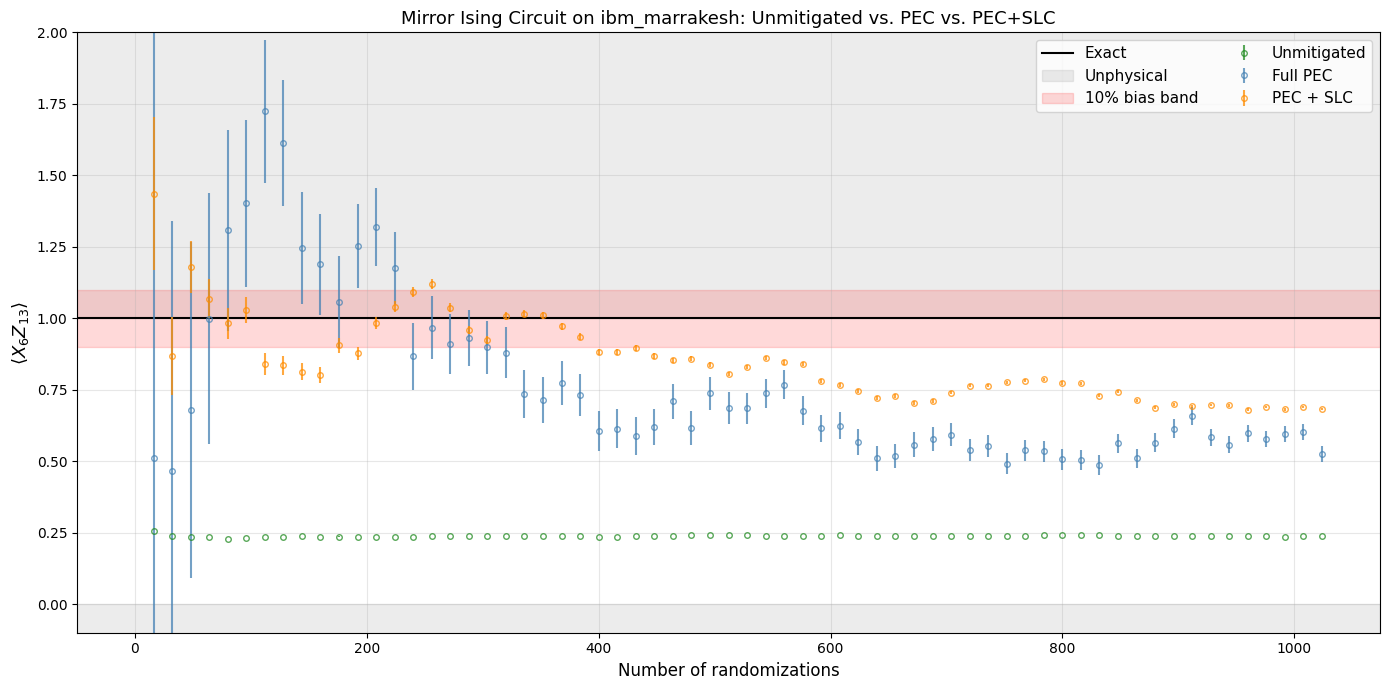

In [34]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.axhline(1.0, color="black", linewidth=1.5, label="Exact")
ax.fill_between([-50, NUM_RANDOMIZATIONS + 50], -10, 0, color="grey", alpha=0.15, label="Unphysical")
ax.fill_between([-50, NUM_RANDOMIZATIONS + 50], 1, 10, color="grey", alpha=0.15)
ax.fill_between(
    [-50, NUM_RANDOMIZATIONS + 50], 1 - CHOSEN_BIAS_TOLERANCE, 1 + CHOSEN_BIAS_TOLERANCE,
    color="red", alpha=0.15, label=f"{CHOSEN_BIAS_TOLERANCE*100:.0f}% bias band"
)

colors = {
    "Unmitigated": "forestgreen",
    "Full PEC": "steelblue",
    "PEC + SLC": "darkorange",
    "PEC + SLC + PS": "purple",
}
x_vals = list(range(steps, NUM_RANDOMIZATIONS + 1, steps))

for label, res in results.items():
    ax.errorbar(
        x_vals[:len(res)],
        [r[0] for r in res],
        yerr=[r[1] for r in res],
        alpha=0.75,
        marker="o",
        linestyle="",
        markerfacecolor="none",
        markersize=4,
        color=colors.get(label, "gray"),
        label=label,
    )

ax.set_ylabel(r"$\langle X_{6}Z_{13}\rangle$", fontsize=13)
ax.set_xlabel("Number of randomizations", fontsize=12)
ax.set_title(
    f"Mirror Ising Circuit on {backend.name}: Unmitigated vs. PEC vs. PEC+SLC",
    fontsize=13,
)
ax.grid(alpha=0.3)
ax.legend(ncols=2, fontsize=11)
ax.set_ylim([-0.1, 2.0])
ax.set_xlim([-50, NUM_RANDOMIZATIONS + 50])
plt.tight_layout()
plt.show()


### Results Summary

| Metric | Unmitigated | Full PEC | PEC + SLC | PEC + SLC + PS |
|--------|------------|---------|----------|----------------|
| **Expectation value** | Suppressed by noise | Closest to ideal | Within bias tolerance | Best accuracy |
| **Sampling cost** | 1x | $\gamma^2_{\text{PEC}}$ (exponential) | $\gamma^2_{\text{SLC}} \ll \gamma^2_{\text{PEC}}$ | Same as SLC |
| **Convergence** | Fast (low variance) | Slow (high variance) | Moderate | Moderate (fewer shots retained) |
| **Bias** | Large (unmitigated noise) | None | Bounded by `bias_tolerance` | Bounded + reduced |
| **Post-selection** | No | No | No | Yes (qubit-based) |

**Bottom line**: PEC+SLC achieves comparable accuracy to full PEC with dramatically fewer samples. Adding post-selection further improves quality by filtering out shots corrupted by detectable errors. The controlled bias tradeoff makes PEC practical for circuits where full PEC would require an infeasible number of shots.

---

## Beyond SLC: Propagated Noise Absorption (PNA)

While SLC reduces PEC's sampling overhead by pruning irrelevant errors, there's an even more radical approach: **don't cancel the noise at all** — instead, absorb it into the observable.

### The PNA Idea

Propagated Noise Absorption works by:

1. **Learning the noise model** — same `NoiseLearnerV3` pipeline as SLC
2. **Propagating the observable through the anti-noise channels** — instead of injecting anti-noise into the circuit, propagate the observable $O$ backward through the inverse noise channels $\Lambda^{-1}_j$, producing a modified observable $\tilde{O}$
3. **Measuring the noise-mitigating observable** — run the original noisy circuit (no `InjectNoise` needed!) but measure $\tilde{O}$ instead of $O$

$$\langle \tilde{O} \rangle_{\text{noisy}} \approx \langle O \rangle_{\text{ideal}}$$

### Why PNA Matters

| | PEC | PEC + SLC | PNA |
|--|-----|----------|-----|
| **Anti-noise injection** | All errors | Subset of errors | None |
| **Sampling overhead** | $\gamma^2$ (exponential) | $\gamma^2_{\text{SLC}}$ (reduced) | **1x** (no overhead!) |
| **Observable modification** | None | None | Observable grows in Pauli weight |
| **Limitation** | Sampling cost | Residual bias | Observable complexity |
| **Best for** | Small circuits | Medium circuits, local observables | Large circuits, simple observables |

PNA trades sampling overhead for **observable complexity** — the propagated observable $\tilde{O}$ has more Pauli terms than $O$. This is manageable when the original observable is simple (e.g., $\frac{1}{N}\sum_i Z_i$) and the circuit structure limits how far noise propagates.

The [Qiskit Advocate Seminar](https://www.crowdcast.io/c/advocate-feb-2026-seminar) demonstrated PNA achieving near-ideal expectation values on a 30-qubit mirrored Ising circuit.

PNA + post-selection + TREX recovered the ideal value from ~0.84 (unmitigated) to ~0.99 — with **zero sampling overhead**.

---

## Conclusion

Shaded Light Cones transform PEC from a theoretically exact but practically infeasible technique into a **tunable, scalable** error mitigation tool. The key ideas:

1. **Not all errors matter** — errors outside the observable's light cone can be safely ignored
2. **Classical preprocessing pays off** — forward/backward bound computation is cheap compared to the QPU savings, and scales with available classical resources (threads, timeout)
3. **The tradeoff is explicit** — you choose the bias tolerance and get the corresponding sampling cost reduction
4. **It integrates seamlessly** — `local_scales` plugs directly into samplomatic's `InjectNoise` annotation
5. **Post-selection compounds** — qubit-based post-selection further improves quality at the cost of retained shot fraction

### The SLC Pipeline at a Glance

```
Circuit + Observable
       │
       ├─→ Transpile & Box (samplomatic)
       │
       ├─→ Forward bounds ─→ Tighten (speed limits) ─┐
       │                                              ├─→ Merge ─→ Local Scales
       ├─→ Backward bounds ───────────────────────────┘         │
       │                                                        │
       ├─→ NoiseLearnerV3 (QPU) ─→ Learned rates ──────────────┘
       │
       └─→ Executor (QPU) with local_scales ─→ Post-process ─→ Mitigated ⟨O⟩
```

### What's Next: The Error Mitigation Decision Tree

| When to use... | Condition |
|---------------|-----------|
| **TREX only** | Shallow circuits, measurement-dominated noise |
| **ZNE** | Moderate depth, no noise model available |
| **Full PEC** | Small circuits ($\gamma^2 < 10^4$), need zero bias |
| **PEC + SLC** | Medium circuits, local observable, willing to accept bounded bias |
| **PNA** | Large circuits, simple observable, zero sampling overhead needed |

For an intelligent framework that automatically selects the best error mitigation strategy for a given circuit, see the [Adaptive Error Mitigation Framework (QAMP 2025)](https://github.com/KurianUthuppu/adaptive_error_mitigation). SLC-optimized PEC and PNA could be integrated as additional strategies, triggered by heuristics based on circuit depth, observable locality, and available sampling budget.

---

## References

**Documentation**:
- [qiskit-addon-slc Documentation](https://qiskit.github.io/qiskit-addon-slc/)
- [qiskit-addon-slc Getting Started Tutorial](https://qiskit.github.io/qiskit-addon-slc/tutorials/01_getting_started.html)
- [Samplomatic Documentation](https://qiskit.github.io/samplomatic)
- [IBM Quantum Primitives](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime)

**Related notebooks**:
- [Samplomatic & Executor: IBM's Phase 3 Primitives](samplomatic_and_executor.ipynb)
- [Adaptive Error Mitigation Framework (QAMP 2025)](https://github.com/KurianUthuppu/adaptive_error_mitigation)

**Seminars**:
- [Qiskit Advocate Seminar: Shaded Light Cones & PNA (Feb 2026)](https://www.crowdcast.io/c/advocate-feb-2026-seminar)

In [ ]:
import qiskit
import sys

print("--- Disclosure ---")
print("AI tool used - Claude Code (Claude Sonnet 4.6, Anthropic)")
print(f"\nLibrary versions:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  Qiskit     : {qiskit.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Matplotlib : {plt.matplotlib.__version__}")

--- Disclosure ---
AI tool used - Claude Code (Claude Opus 4.6, Anthropic)

Library versions:
  Python     : 3.10.12
  Qiskit     : 2.3.0
  NumPy      : 2.0.2
  Matplotlib : 3.10.8
